In [ ]:
print("Name:- Yash Chavan")
print("Roll no:- TACO23102\n")

Name:- Yash Chavan
Roll no:- TACO23102



In [1]:
pip install yfinance --user

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression

google = yf.Ticker("GOOG")

In [25]:
df = google.history(period='1d', interval="1m")
print(df.head())

                                 Open        High         Low       Close  \
Datetime                                                                    
2026-05-08 09:30:00-04:00  394.417511  395.500000  394.170013  394.980011   
2026-05-08 09:31:00-04:00  394.859985  395.369995  394.220001  394.630005   
2026-05-08 09:32:00-04:00  394.570099  395.000000  394.380005  394.910004   
2026-05-08 09:33:00-04:00  394.859985  395.200012  394.350006  394.864288   
2026-05-08 09:34:00-04:00  394.850006  395.000000  394.299988  394.660004   

                           Volume  Dividends  Stock Splits  
Datetime                                                    
2026-05-08 09:30:00-04:00  536048        0.0           0.0  
2026-05-08 09:31:00-04:00   52437        0.0           0.0  
2026-05-08 09:32:00-04:00   36493        0.0           0.0  
2026-05-08 09:33:00-04:00   37260        0.0           0.0  
2026-05-08 09:34:00-04:00   50345        0.0           0.0  


In [26]:
df = google.history(period='1d', interval="1m")
df = df[['Low']]
df.head()

,Low
Datetime,
2026-05-08 09:30:00-04:00,394.170013
2026-05-08 09:31:00-04:00,394.220001
2026-05-08 09:32:00-04:00,394.380005
2026-05-08 09:33:00-04:00,394.350006
2026-05-08 09:34:00-04:00,394.299988


In [27]:
df['seconds_since_midnight'] = (df.index.hour * 3600 +
                                df.index.minute * 60 +
                                df.index.second)

X = df[['seconds_since_midnight']].values
y = df['Low'].values


In [28]:


offset = int(0.10*len(df))
X_train = X[:-offset]
y_train = y[:-offset]
X_test  = X[-offset:]
y_test  = y[-offset:]

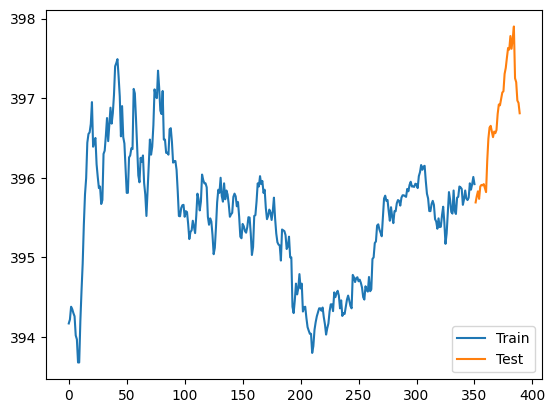

In [29]:
plt.plot(range(0,len(y_train)),y_train, label='Train')
plt.plot(range(len(y_train),len(y)),y_test,label='Test')
plt.legend()
plt.show()

In [30]:


# Create a logistic regression model
model = LinearRegression()

# Fit the model

model.fit(X, y)


# Evaluate the model
score = model.score(X, y)
print("Model score:", score)


Model score: 3.024093711823106e-05


In [35]:
forecast = model.predict(X_test[0:1])
print(f'Real data for time 0: {y_train[-1]}')
print(f'Real data for time 1: {y_test[0]}')
print(f'Pred data for time 1: {forecast[0]}')


Real data for time 0: 395.9200134277344
Real data for time 1: 395.69000244140625
Pred data for time 1: 395.6434850456212
